# Fuel Station Transaction & Employee Analysis

This project performs a comprehensive analysis of fuel station operations, combining transaction data with employee records to uncover sales trends, peak hours, and workforce insights.

---

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Data Acquisition and Initial Loading
In this step, we load the raw datasets: `transactions_pumb150k.csv` (containing sales records) and `employee_pumb.csv` (containing staff details).

In [245]:
tran = pd.read_csv('transactions_pumb150k.csv', on_bad_lines='skip', low_memory=False)
emp = pd.read_csv('employee_pumb.csv')

In [246]:
tran.head()


,Invoice_ID,DateTime,EmpID,Counter_Station,Fuel_Type,Liters_Sold,Price_Per_Liter,Total_Amount,Payment_Method
0,INV20240902-0001,2024-09-02 13:31,EMP023,C4,Petrol,75.03,100.79,7562.27,Cash
1,INV20241215-0002,2024-12-15 21:08,EMP009,C2,Petrol,143.51,101.81,14610.75,Cash
2,INV20240728-0003,2024-07-28 01:37,EMP005,C1,Petrol,194.6,107.25,20870.85,card
3,inv20240626-0004,2024-06-26 13:16,EMP007,C2,Petrol,88.8,107.58,9553.1,UPI
4,INV20241006-0005,06/10/2024 14:17,EMP001,C1,petrol,34.54,95.68,3304.79,Card


In [247]:
emp.head()

,EmpID,Employee_Name,Age,Gender,Role,Working_Hours,Joining_Date,Salary,Phone_Number
0,EMP001,Ramesh Kumar,35.0,FEMALE,Supervisor,10,20/05/2019,80000.0,9945175914
1,EMP002,ANITA SHARMA,NaN,FEMALE,Cashier,10,15/07/2020,25847.0,9517451630
2,EMP003,rahul das,61.0,male,Supervisor,8,11/11/2022,NaN,935196486
3,EMP004,Suresh Nair,46.0,Female,Cashier,10,13/06/2021,NaN,918190067
4,EMP005,Deepak Verma,0.0,male,Supervisor,6,2019-12-14,12491.0,972021653


In [248]:
df = pd.merge(tran, emp, on='EmpID')

In [249]:
df.head()

,Invoice_ID,DateTime,EmpID,Counter_Station,Fuel_Type,Liters_Sold,Price_Per_Liter,Total_Amount,Payment_Method,Employee_Name,Age,Gender,Role,Working_Hours,Joining_Date,Salary,Phone_Number
0,INV20240902-0001,2024-09-02 13:31,EMP023,C4,Petrol,75.03,100.79,7562.27,Cash,Priya Sharma,61.0,FEMALE,Supervisor,10,25/01/2019,24583.0,9113220074
1,INV20241215-0002,2024-12-15 21:08,EMP009,C2,Petrol,143.51,101.81,14610.75,Cash,neha nair,0.0,Female,Fuel_Attendant,6,01/06/2020,NaN,934245850
2,INV20240728-0003,2024-07-28 01:37,EMP005,C1,Petrol,194.6,107.25,20870.85,card,Deepak Verma,0.0,male,Supervisor,6,2019-12-14,12491.0,972021653
3,inv20240626-0004,2024-06-26 13:16,EMP007,C2,Petrol,88.8,107.58,9553.1,UPI,VIVEK MENON,0.0,male,Fuel_Attendant,10,2020-11-15,80000.0,9129876770
4,INV20241006-0005,06/10/2024 14:17,EMP001,C1,petrol,34.54,95.68,3304.79,Card,Ramesh Kumar,35.0,FEMALE,Supervisor,10,20/05/2019,80000.0,9945175914


In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246445 entries, 0 to 246444
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Invoice_ID       246445 non-null  object 
 1   DateTime         246445 non-null  object 
 2   EmpID            246445 non-null  object 
 3   Counter_Station  246445 non-null  object 
 4   Fuel_Type        246445 non-null  object 
 5   Liters_Sold      246445 non-null  object 
 6   Price_Per_Liter  239002 non-null  object 
 7   Total_Amount     239002 non-null  object 
 8   Payment_Method   246442 non-null  object 
 9   Employee_Name    246445 non-null  object 
 10  Age              206751 non-null  float64
 11  Gender           246445 non-null  object 
 12  Role             246445 non-null  object 
 13  Working_Hours    246445 non-null  int64  
 14  Joining_Date     246445 non-null  object 
 15  Salary           138033 non-null  float64
 16  Phone_Number     246445 non-null  int6

## 2. Data Cleaning and Merging
To perform a unified analysis, we merge the transaction and employee data on the `EmpID` column. We also handle data quality issues such as duplicates, inconsistent date formats, and corrupted numeric strings.

In [251]:
df.drop_duplicates(inplace=True)

In [252]:
df['DateTime'] = pd.to_datetime(df['DateTime'], format='mixed', errors='coerce')
df['Joining_Date'] = pd.to_datetime(df['Joining_Date'], format='mixed', dayfirst=True, errors='coerce')

# Convert numeric columns safely, coercing errors to NaN
df['Liters_Sold'] = pd.to_numeric(df['Liters_Sold'], errors='coerce')
df['Price_Per_Liter'] = pd.to_numeric(df['Price_Per_Liter'], errors='coerce')
df['Total_Amount'] = pd.to_numeric(df['Total_Amount'], errors='coerce')

In [253]:
# Fixing negative values by replacing them with NaN
numeric_cols = ['Liters_Sold', 'Price_Per_Liter', 'Total_Amount']

for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f'Found {negative_count} negative values in {col}. Replacing with NaN.')
        df.loc[df[col] < 0, col] = np.nan

# Quick check to confirm
print("\nNegative values remaining:")
print((df[numeric_cols] < 0).sum())

Found 2437 negative values in Liters_Sold. Replacing with NaN.
Found 2364 negative values in Total_Amount. Replacing with NaN.

Negative values remaining:
Liters_Sold        0
Price_Per_Liter    0
Total_Amount       0
dtype: int64


## 3. Exploratory Data Analysis (EDA)
We analyze the distribution of key metrics to understand the 'shape' of our data and identify any physical impossibilities (like negative fuel amounts) or significant outliers.

In [254]:
df[df["Age"]>100]

,Invoice_ID,DateTime,EmpID,Counter_Station,Fuel_Type,Liters_Sold,Price_Per_Liter,Total_Amount,Payment_Method,Employee_Name,Age,Gender,Role,Working_Hours,Joining_Date,Salary,Phone_Number


In [255]:
df.isnull().sum().count()/len(df)*100

np.float64(0.011920957042480682)

In [256]:

df.isnull().sum()

,0
Invoice_ID,0
DateTime,1
EmpID,0
Counter_Station,0
Fuel_Type,0
Liters_Sold,2437
Price_Per_Liter,4312
Total_Amount,6678
Payment_Method,3
Employee_Name,0


array([[<Axes: title={'center': 'DateTime'}>,
        <Axes: title={'center': 'Liters_Sold'}>,
        <Axes: title={'center': 'Price_Per_Liter'}>],
       [<Axes: title={'center': 'Total_Amount'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Working_Hours'}>],
       [<Axes: title={'center': 'Joining_Date'}>,
        <Axes: title={'center': 'Salary'}>,
        <Axes: title={'center': 'Phone_Number'}>]], dtype=object)

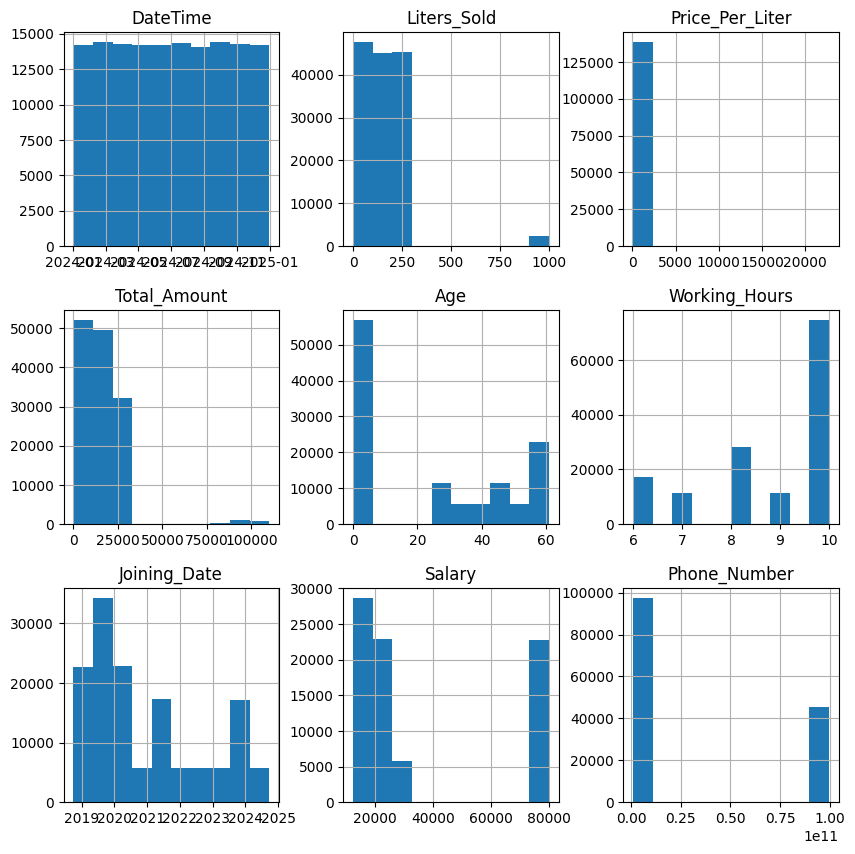

In [257]:
df.hist(figsize=(10, 10))


```markdown
### 1. Data Distributions
Let's visualize the density and spread of our main numerical columns.
```

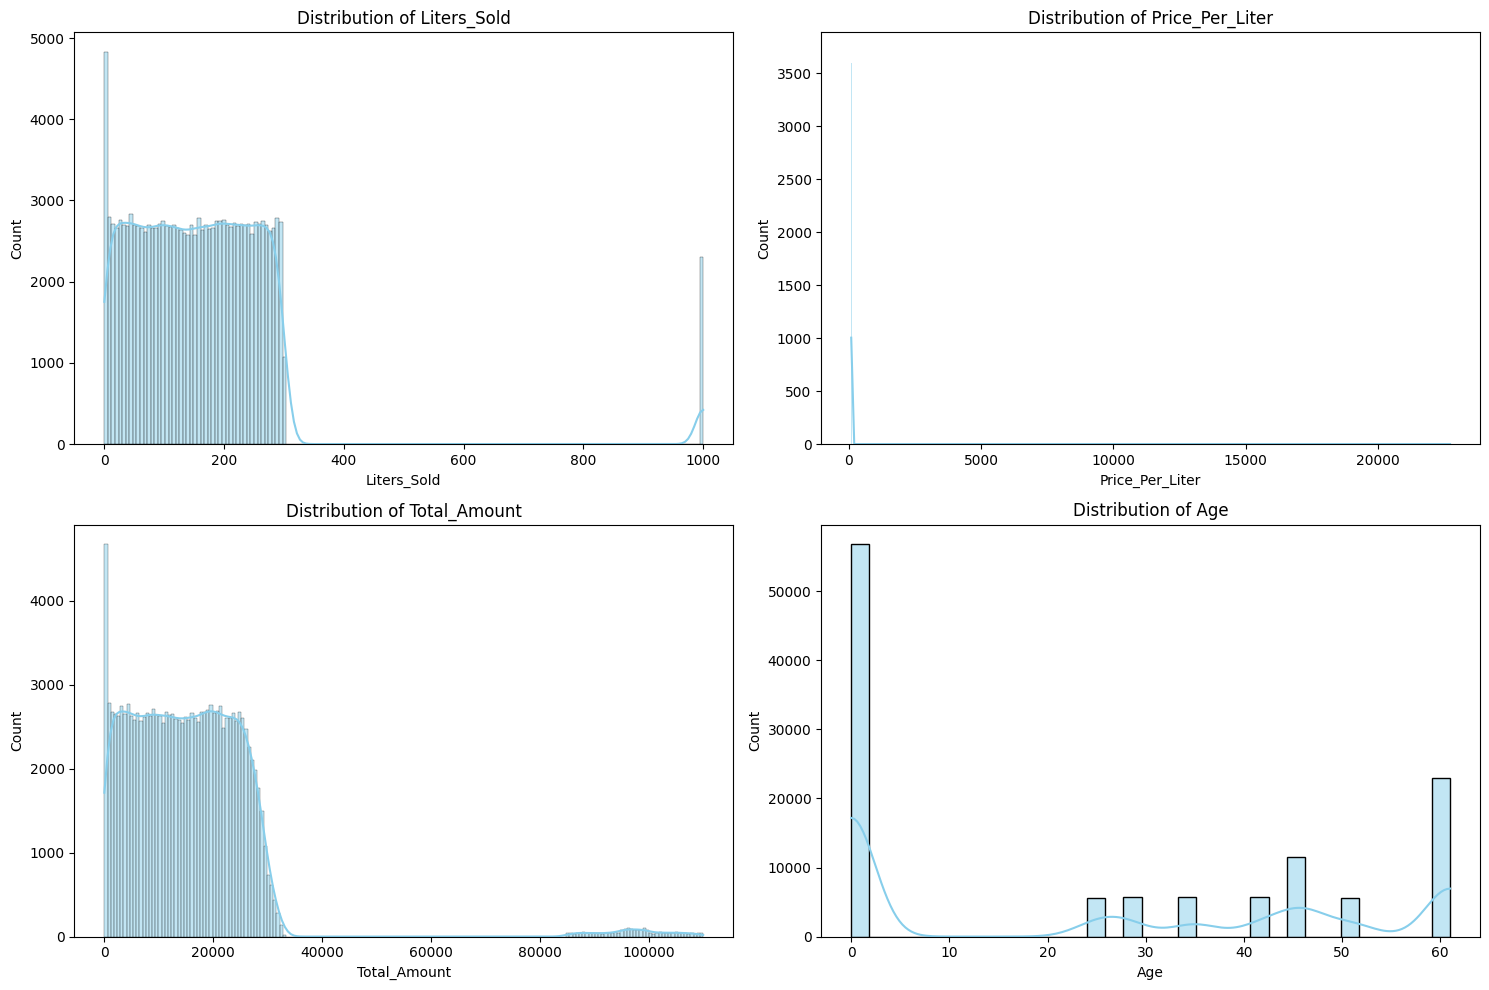

In [258]:
# Visualizing distributions of key numerical features
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['Liters_Sold', 'Price_Per_Liter', 'Total_Amount', 'Age']
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

```markdown
### 2. Outlier Detection (IQR Method)
We will now use boxplots to see the spread and identify values that fall significantly outside the typical range.
```

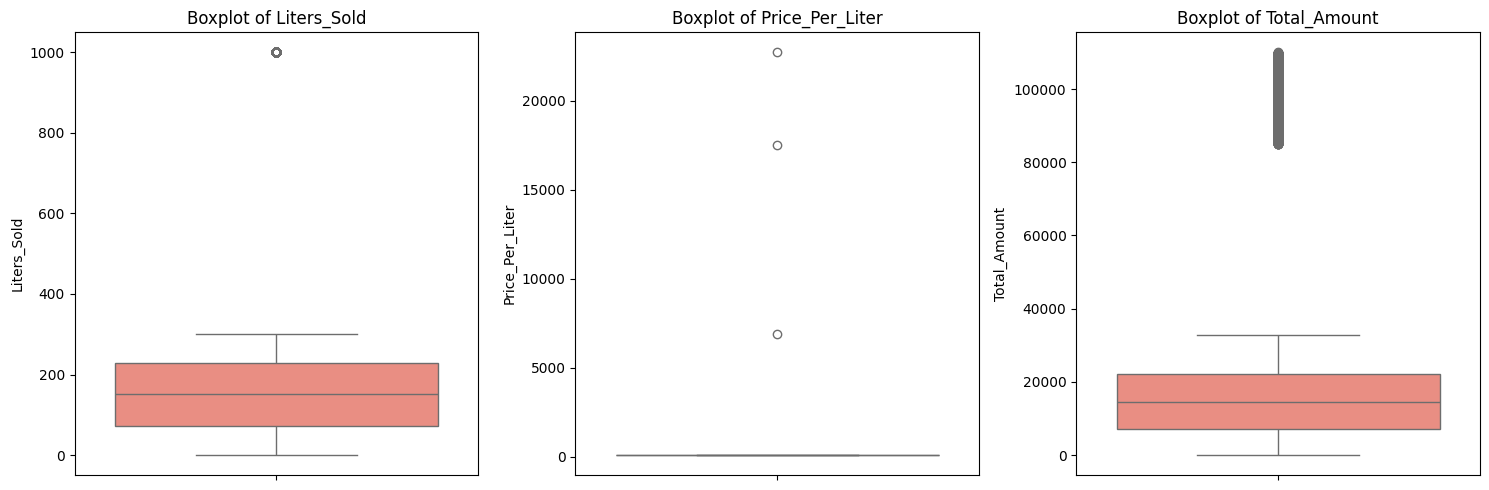

Liters_Sold: Found 2307 outliers (Values below -160.79 or above 460.89)
Price_Per_Liter: Found 3 outliers (Values below 77.62 or above 117.41)
Total_Amount: Found 2240 outliers (Values below -15607.74 or above 44708.81)


In [259]:
# Boxplots for outlier visualization
plt.figure(figsize=(15, 5))

for i, col in enumerate(['Liters_Sold', 'Price_Per_Liter', 'Total_Amount'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# Calculating the number of outliers using IQR
def count_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['Liters_Sold', 'Price_Per_Liter', 'Total_Amount']:
    num, low, high = count_outliers(df, col)
    print(f"{col}: Found {num} outliers (Values below {low:.2f} or above {high:.2f})")

In [260]:
df['Price_Per_Liter'] = df['Price_Per_Liter'].fillna(df['Price_Per_Liter'].mean())

In [261]:
df['Liters_Sold']=df['Liters_Sold'].fillna(df['Liters_Sold'].mean())

In [262]:
df['Total_Amount'] = df['Total_Amount'].fillna(
  ( ( df['Price_Per_Liter'])*(df['Liters_Sold']))
)

In [263]:
df['Salary'] =df['Salary'].fillna(
    df['Salary'].median()
)

In [264]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

In [265]:
df.isnull().sum()

,0
Invoice_ID,0
DateTime,1
EmpID,0
Counter_Station,0
Fuel_Type,0
Liters_Sold,0
Price_Per_Liter,0
Total_Amount,0
Payment_Method,3
Employee_Name,0


## 4. Feature Standardization
Categorical fields are standardized (stripping whitespace and proper casing) to ensure accurate grouping and visualization.

In [266]:
df.dropna()

,Invoice_ID,DateTime,EmpID,Counter_Station,Fuel_Type,Liters_Sold,Price_Per_Liter,Total_Amount,Payment_Method,Employee_Name,Age,Gender,Role,Working_Hours,Joining_Date,Salary,Phone_Number
0,INV20240902-0001,2024-09-02 13:31:00,EMP023,C4,Petrol,75.03,100.79,7562.27,Cash,Priya Sharma,61.0,FEMALE,Supervisor,10,2019-01-25,24583.0,9113220074
1,INV20241215-0002,2024-12-15 21:08:00,EMP009,C2,Petrol,143.51,101.81,14610.75,Cash,neha nair,0.0,Female,Fuel_Attendant,6,2020-06-01,22454.0,934245850
2,INV20240728-0003,2024-07-28 01:37:00,EMP005,C1,Petrol,194.60,107.25,20870.85,card,Deepak Verma,0.0,male,Supervisor,6,2019-12-14,12491.0,972021653
3,inv20240626-0004,2024-06-26 13:16:00,EMP007,C2,Petrol,88.80,107.58,9553.10,UPI,VIVEK MENON,0.0,male,Fuel_Attendant,10,2020-11-15,80000.0,9129876770
4,INV20241006-0005,2024-06-10 14:17:00,EMP001,C1,petrol,34.54,95.68,3304.79,Card,Ramesh Kumar,35.0,FEMALE,Supervisor,10,2019-05-20,80000.0,9945175914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219601,INV20240506-149998,2024-05-06 17:18:00,EMP009,C1,diesel,52.42,91.69,4806.39,UPI,neha nair,0.0,Female,Fuel_Attendant,6,2020-06-01,22454.0,934245850
219602,INV20241104-149999,2024-11-04 17:28:00,EMP002,C4,Petrol,211.41,106.73,22563.79,Cash,ANITA SHARMA,25.0,FEMALE,Cashier,10,2020-07-15,25847.0,9517451630
219603,INV20240920-150000,2024-09-20 20:07:00,EMP015,C4,Diesel,102.04,99.53,10156.04,Card,Sunita Devi,61.0,Male,Cashier,7,2021-06-02,16728.0,961967675
232302,INV20240523-135121,2024-05-23 04:07:00,EMP020,C2,Diesel,84.19,93.26,7851.56,Card,SURESH DAS,0.0,FEMALE,Supervisor,10,2023-11-25,27982.0,9510999826


### COVERT TEXT TO CAPITALIZED

In [267]:
df['Fuel_Type']=df['Fuel_Type'].str.strip().str.capitalize()
df['Fuel_Type'] = df['Fuel_Type'].replace('8', 'Diesel')
df['Fuel_Type'] = df['Fuel_Type'].replace('Dies82.11', 'Diesel')
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel'], dtype=object)

In [289]:
cols = ['Counter_Station', 'Employee_Name', 'Role', 'Payment_Method','Gender']
# Apply strip and capitalize to each element in the selected columns
df[cols] = df[cols].astype(str).apply(lambda x: x.str.strip().str.capitalize())

# Display unique values for each to verify the fix
for col in cols:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in Counter_Station: ['C4' 'C2' 'C1' 'C3']
Unique values in Employee_Name: ['Priya  sharma' 'Neha nair' 'Deepak verma' 'Vivek menon' 'Ramesh kumar'
 'Rahul das' 'Pooja singh' 'Suresh das' 'Anita sharma' 'Arjun das'
 'Sanjay kumar' 'Anu  varma' 'Rajesh nair' 'Ajay singh' 'Meera nair'
 'Sunita devi' 'Vikas nair' 'Suresh  nair' 'Rahul shah' 'Arvind kumar'
 'Karthik raj' 'Akhil  raj' 'Kiran  patel' 'Ritu sharma' 'Rohit kumar']
Unique values in Role: ['Supervisor' 'Fuel_attendant' 'Cashier']
Unique values in Payment_Method: ['Cash' 'Card' 'Upi' 'Nan']
Unique values in Gender: ['Female' 'Male' 'M']


### 1. Daily Sales Trend
Let's see how the total amount of sales fluctuates over time.

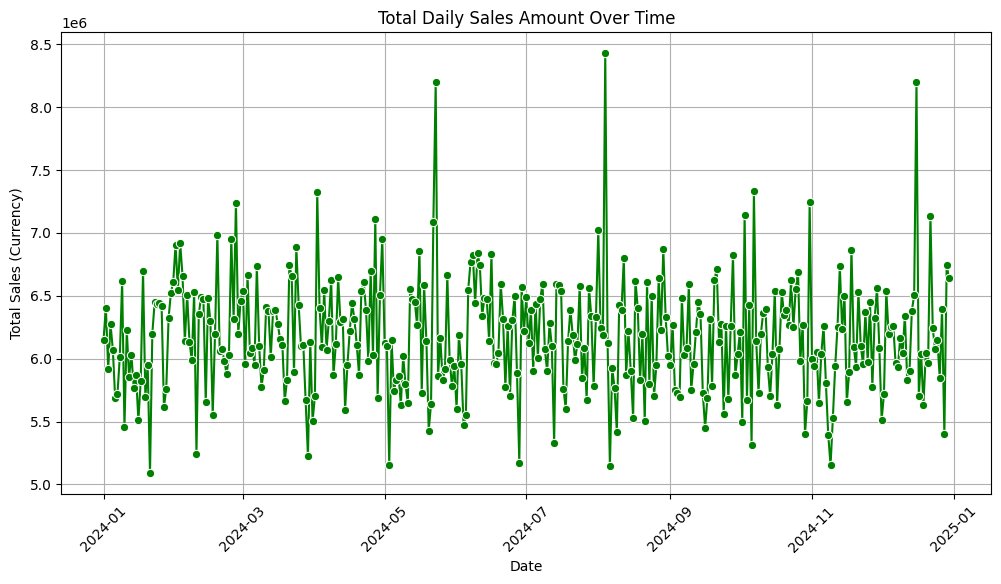

In [269]:
# Resample and plot total daily sales
daily_sales = df.set_index('DateTime')['Total_Amount'].resample('D').sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='DateTime', y='Total_Amount', marker='o', color='green')
plt.title('Total Daily Sales Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (Currency)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 2. Fuel Type Distribution
Which fuel type is the most popular in terms of Liters sold?

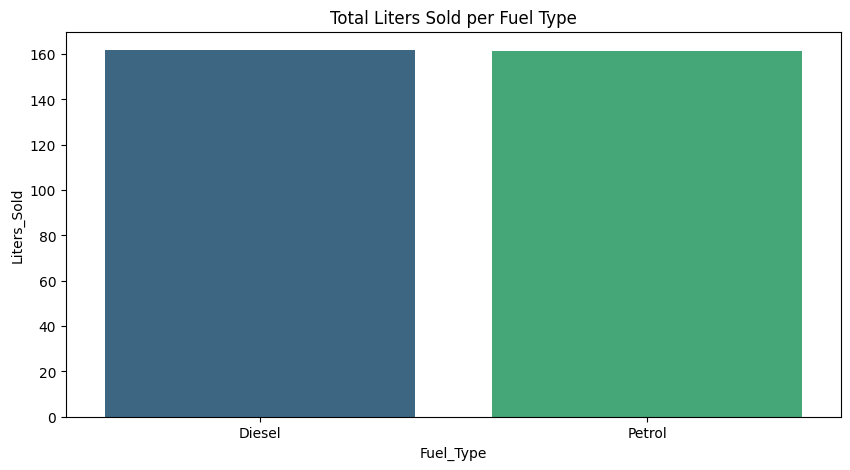

In [270]:
# Compare Liters Sold by Fuel Type
fuel_analysis = df.groupby('Fuel_Type')['Liters_Sold'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=fuel_analysis, x='Fuel_Type', y='Liters_Sold', hue='Fuel_Type', palette='viridis', legend=False)
plt.title('Total Liters Sold per Fuel Type')
plt.show()

In [271]:
df.head()

,Invoice_ID,DateTime,EmpID,Counter_Station,Fuel_Type,Liters_Sold,Price_Per_Liter,Total_Amount,Payment_Method,Employee_Name,Age,Gender,Role,Working_Hours,Joining_Date,Salary,Phone_Number
0,INV20240902-0001,2024-09-02 13:31:00,EMP023,C4,Petrol,75.03,100.79,7562.27,Cash,Priya sharma,61.0,FEMALE,Supervisor,10,2019-01-25,24583.0,9113220074
1,INV20241215-0002,2024-12-15 21:08:00,EMP009,C2,Petrol,143.51,101.81,14610.75,Cash,Neha nair,0.0,Female,Fuel_attendant,6,2020-06-01,22454.0,934245850
2,INV20240728-0003,2024-07-28 01:37:00,EMP005,C1,Petrol,194.60,107.25,20870.85,Card,Deepak verma,0.0,male,Supervisor,6,2019-12-14,12491.0,972021653
3,inv20240626-0004,2024-06-26 13:16:00,EMP007,C2,Petrol,88.80,107.58,9553.10,Upi,Vivek menon,0.0,male,Fuel_attendant,10,2020-11-15,80000.0,9129876770
4,INV20241006-0005,2024-06-10 14:17:00,EMP001,C1,Petrol,34.54,95.68,3304.79,Card,Ramesh kumar,35.0,FEMALE,Supervisor,10,2019-05-20,80000.0,9945175914


In [272]:
df['Month'] = df['DateTime'].dt.strftime('%b')
df['Hour'] = df['DateTime'].dt.hour

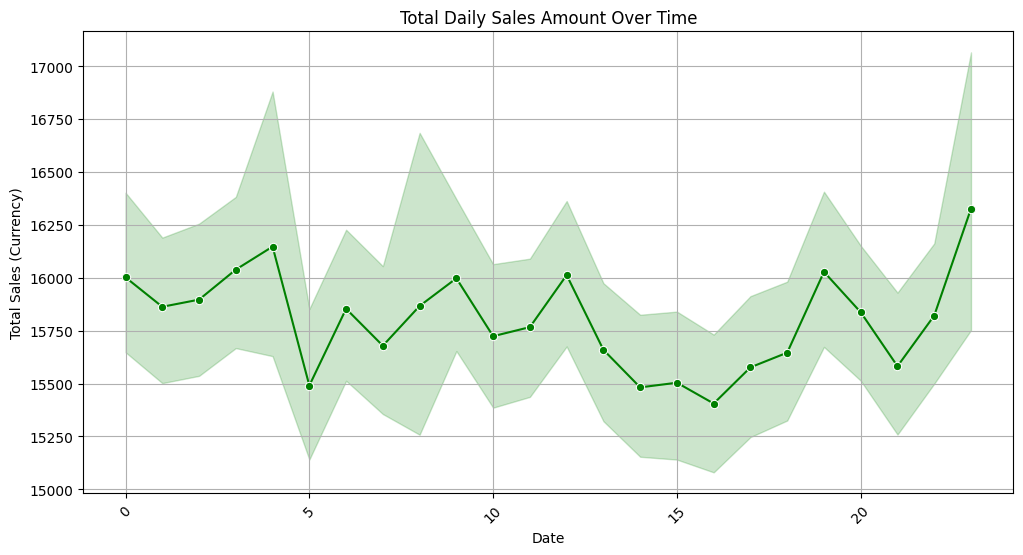

In [273]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Hour', y='Total_Amount', marker='o', color='green')
plt.title('Total Daily Sales Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (Currency)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Numerical Feature Correlation Heatmap
This heatmap visualizes the Pearson correlation coefficients between all numerical variables in the dataset.

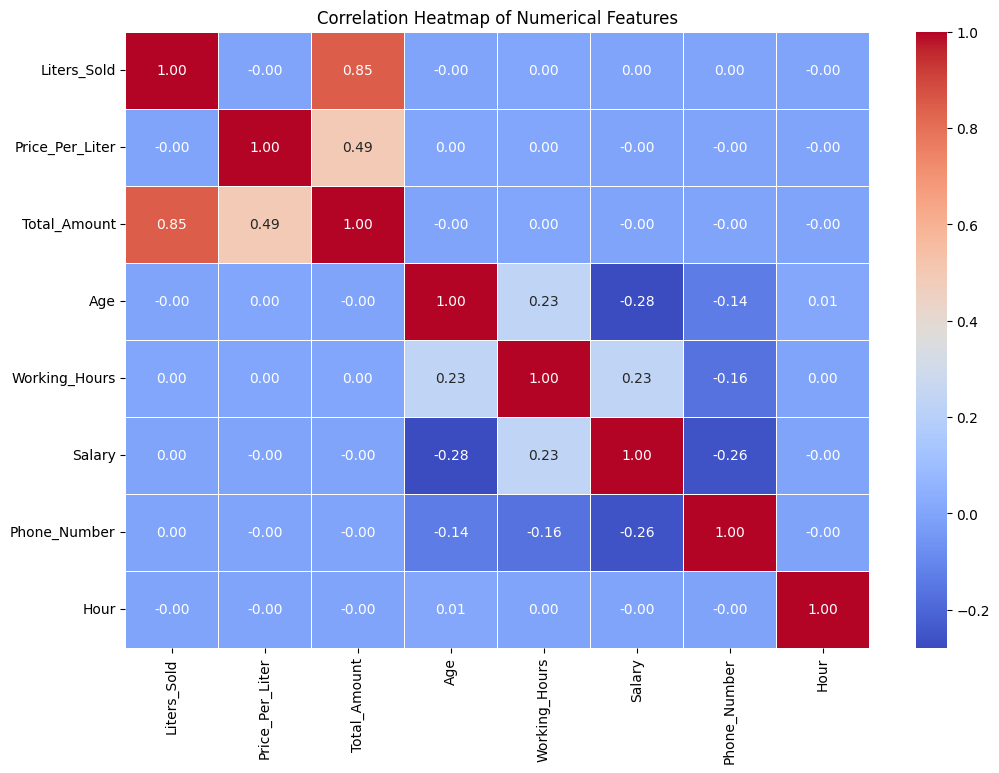

In [274]:
# Select numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 5. Sales and Operational Insights
We visualize sales trends over time, by fuel type, and by counter station to identify the highest revenue drivers and busiest service points.

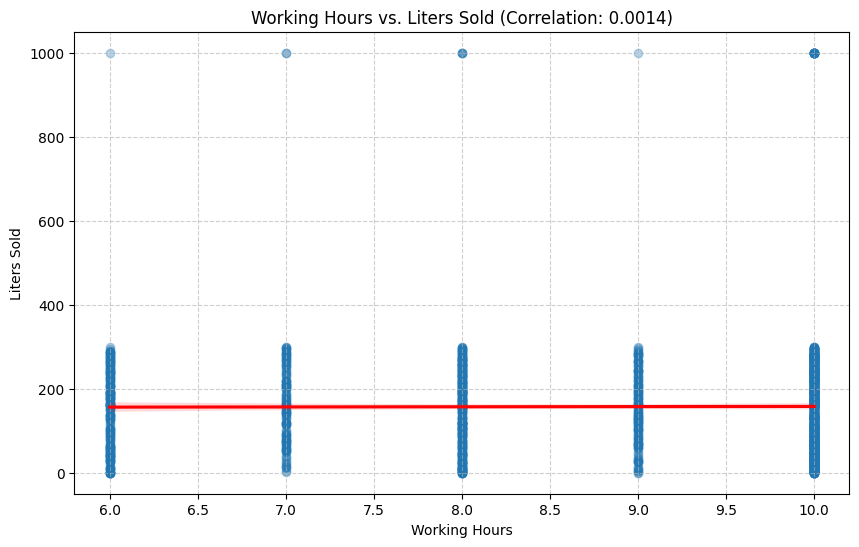

Pearson Correlation Coefficient: 0.0014
P-value: 5.9402e-01


In [290]:
import scipy.stats as stats

# Prepare data by removing rows where either Working_Hours or Liters_Sold is NaN
corr_data_vol = df[['Working_Hours', 'Liters_Sold']].dropna()

# Calculate Pearson correlation
correlation, p_value = stats.pearsonr(corr_data_vol['Working_Hours'], corr_data_vol['Liters_Sold'])

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=corr_data_vol.sample(min(2000, len(corr_data_vol))), x='Working_Hours', y='Liters_Sold',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Working Hours vs. Liters Sold (Correlation: {correlation:.4f})')
plt.xlabel('Working Hours')
plt.ylabel('Liters Sold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")

## 6. Correlation Analysis
Finally, we perform statistical tests and generate heatmaps to see if factors like employee working hours or salary have any linear relationship with the sales volume processed.

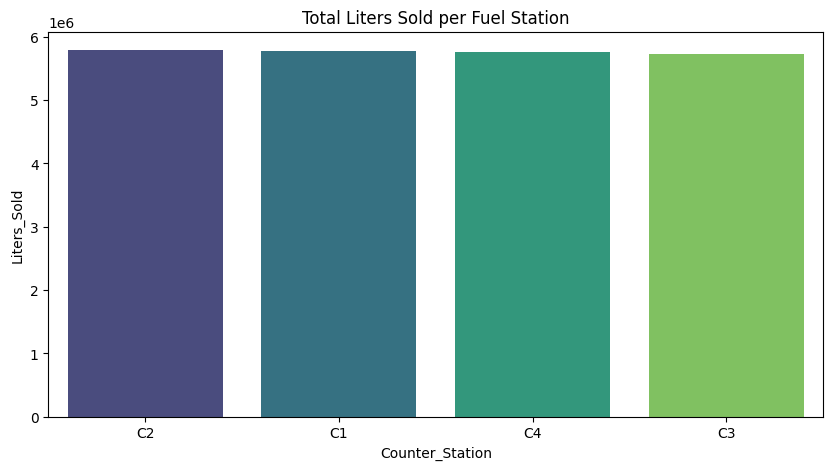

In [276]:
# Compare Liters Sold by Fuel Type
fuel_analysis = df.groupby('Counter_Station')['Liters_Sold'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=fuel_analysis, x='Counter_Station', y='Liters_Sold', hue='Counter_Station', palette='viridis', legend=False)
plt.title('Total Liters Sold per Fuel Station')
plt.show()

### Rush Hour Analysis
We will analyze transaction counts by hour to identify peak busy times.

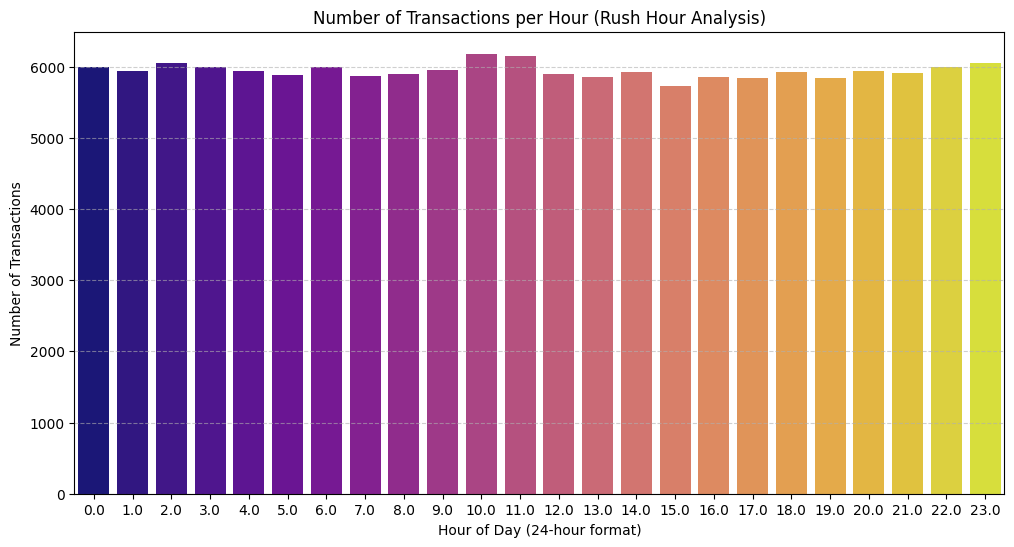

Top 3 busiest hours:


,Hour,Transaction_Count
10,10.0,6181
11,11.0,6154
23,23.0,6054


In [277]:
# Group by hour to find transaction counts
rush_hour_data = df.groupby('Hour').size().reset_index(name='Transaction_Count')

# Visualize transaction frequency by hour
plt.figure(figsize=(12, 6))
sns.barplot(data=rush_hour_data, x='Hour', y='Transaction_Count', palette='plasma', hue='Hour', legend=False)
plt.title('Number of Transactions per Hour (Rush Hour Analysis)')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Identify top 3 rush hours
top_hours = rush_hour_data.sort_values(by='Transaction_Count', ascending=False).head(3)
print("Top 3 busiest hours:")
display(top_hours)

### Weekday vs. Weekend Analysis
We categorize transactions to see if customer behavior shifts during the weekend.

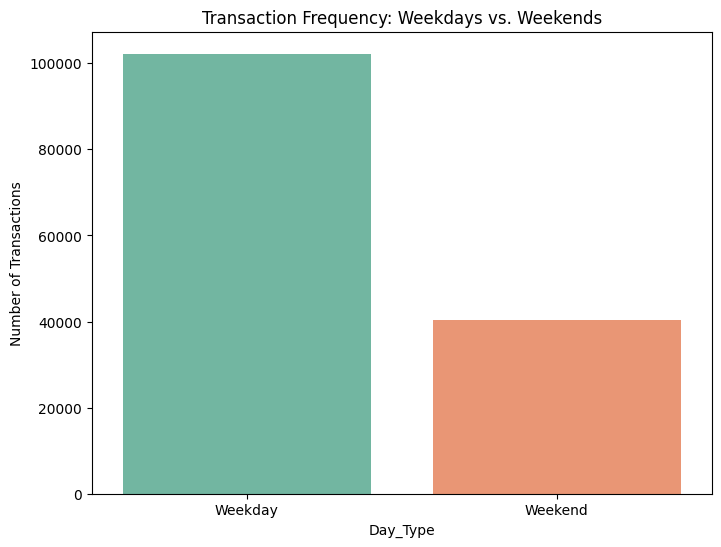

Average transactions per Weekday: 393.10
Average transactions per Weekend day: 388.47


In [278]:
# Create a Day_Type column (0-4 are Mon-Fri, 5-6 are Sat-Sun)
df['Day_Name'] = df['DateTime'].dt.day_name()
df['Is_Weekend'] = df['DateTime'].dt.dayofweek.isin([5, 6])

# Group and count transactions
weekday_weekend_counts = df.groupby('Is_Weekend').size().reset_index(name='Transaction_Count')
weekday_weekend_counts['Day_Type'] = weekday_weekend_counts['Is_Weekend'].map({False: 'Weekday', True: 'Weekend'})

# Visualization
plt.figure(figsize=(8, 6))
sns.barplot(data=weekday_weekend_counts, x='Day_Type', y='Transaction_Count', hue='Day_Type', palette='Set2', legend=False)
plt.title('Transaction Frequency: Weekdays vs. Weekends')
plt.ylabel('Number of Transactions')
plt.show()

# Calculate daily average to normalize the comparison (since there are 5 weekdays and 2 weekend days)
days_in_data = (df['DateTime'].max() - df['DateTime'].min()).days
num_weekends = (days_in_data // 7) * 2
num_weekdays = days_in_data - num_weekends

print(f"Average transactions per Weekday: {weekday_weekend_counts.loc[weekday_weekend_counts['Is_Weekend']==False, 'Transaction_Count'].values[0] / num_weekdays:.2f}")
print(f"Average transactions per Weekend day: {weekday_weekend_counts.loc[weekday_weekend_counts['Is_Weekend']==True, 'Transaction_Count'].values[0] / num_weekends:.2f}")

,Fuel_Type,Total_Amount
0,Petrol,1.179245e+09
1,Diesel,1.074142e+09


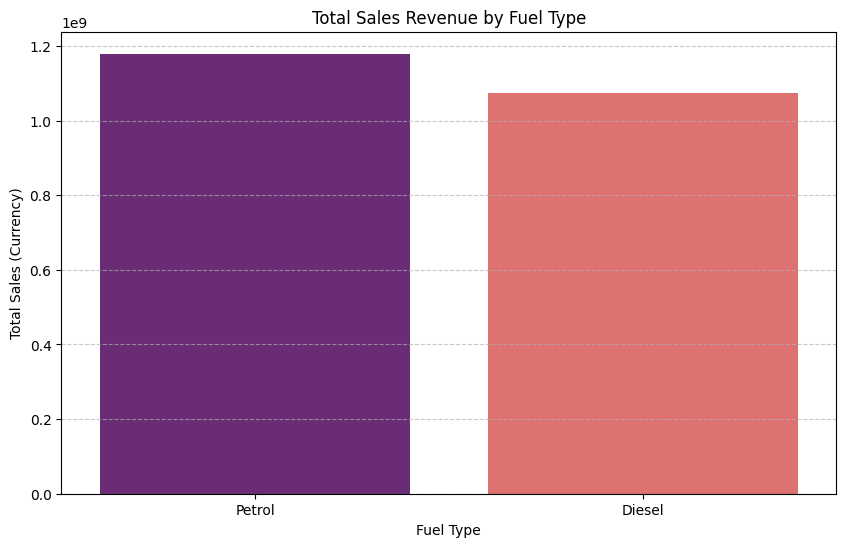

In [279]:
# Calculate total sales by fuel type
fuel_sales = df.groupby('Fuel_Type')['Total_Amount'].sum().sort_values(ascending=False).reset_index()

# Display the numeric results
display(fuel_sales)

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(data=fuel_sales, x='Fuel_Type', y='Total_Amount', palette='magma', hue='Fuel_Type', legend=False)
plt.title('Total Sales Revenue by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Total Sales (Currency)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Busiest Counter Analysis
Identifying which counter station processes the most fuel volume.

,Counter_Station,Liters_Sold
0,C2,5.794402e+06
1,C1,5.771326e+06
2,C4,5.757675e+06
3,C3,5.730539e+06


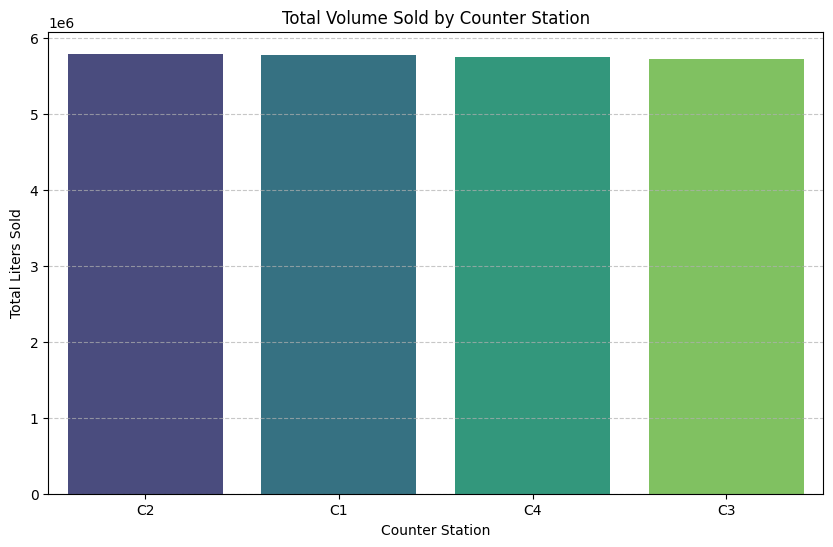

The busiest counter is C2 with 5,794,402.25 liters sold.


In [280]:
# Aggregate Liters Sold by Counter Station
counter_activity = df.groupby('Counter_Station')['Liters_Sold'].sum().sort_values(ascending=False).reset_index()

# Display the numeric results
display(counter_activity)

# Visualize the activity per counter
plt.figure(figsize=(10, 6))
sns.barplot(data=counter_activity, x='Counter_Station', y='Liters_Sold', palette='viridis', hue='Counter_Station', legend=False)
plt.title('Total Volume Sold by Counter Station')
plt.xlabel('Counter Station')
plt.ylabel('Total Liters Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

busiest_counter = counter_activity.iloc[0]
print(f"The busiest counter is {busiest_counter['Counter_Station']} with {busiest_counter['Liters_Sold']:,.2f} liters sold.")

### Monthly Sales Trend
Visualizing how total revenue changes month-over-month.

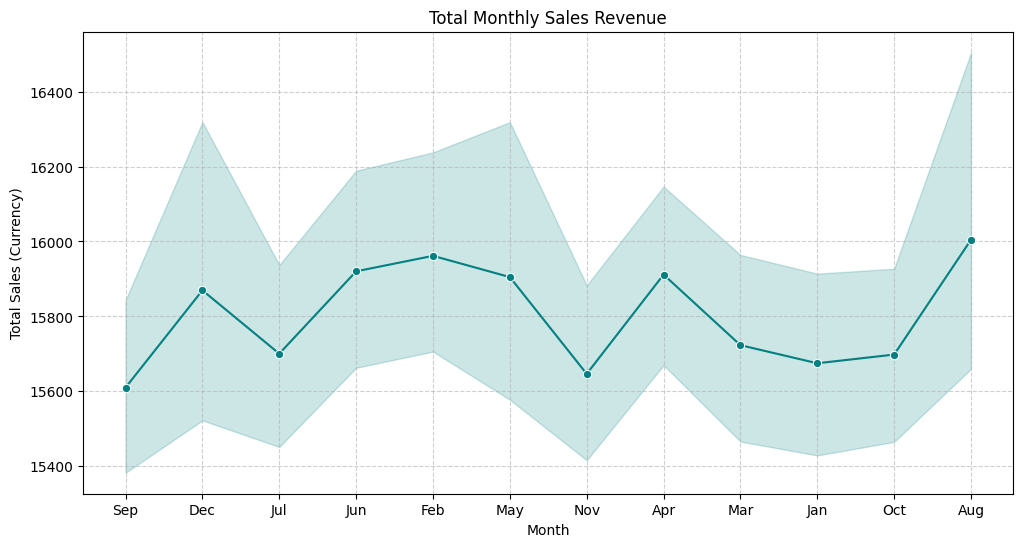

,Month,Total_Amount
1,Aug,1.925828e+08
10,Oct,1.925221e+08
5,Jul,1.911693e+08
7,Mar,1.907068e+08
8,May,1.896027e+08
0,Apr,1.892839e+08
4,Jan,1.875819e+08
6,Jun,1.864581e+08
2,Dec,1.857379e+08
3,Feb,1.832235e+08


In [281]:
# Aggregate total sales by month name
monthly_sales = df.groupby('Month')['Total_Amount'].sum().reset_index()

# Sort months chronologically for the plot
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales['Month'] = pd.Categorical(monthly_sales['Month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('Month')

# Visualize the monthly trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Month', y='Total_Amount', marker='o', color='teal')
plt.title('Total Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Total Sales (Currency)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Display numeric values
display(monthly_sales.sort_values(by='Total_Amount', ascending=False))

### Average Transaction Value by Hour
This analysis helps identify the times of day when customers spend the most per visit.

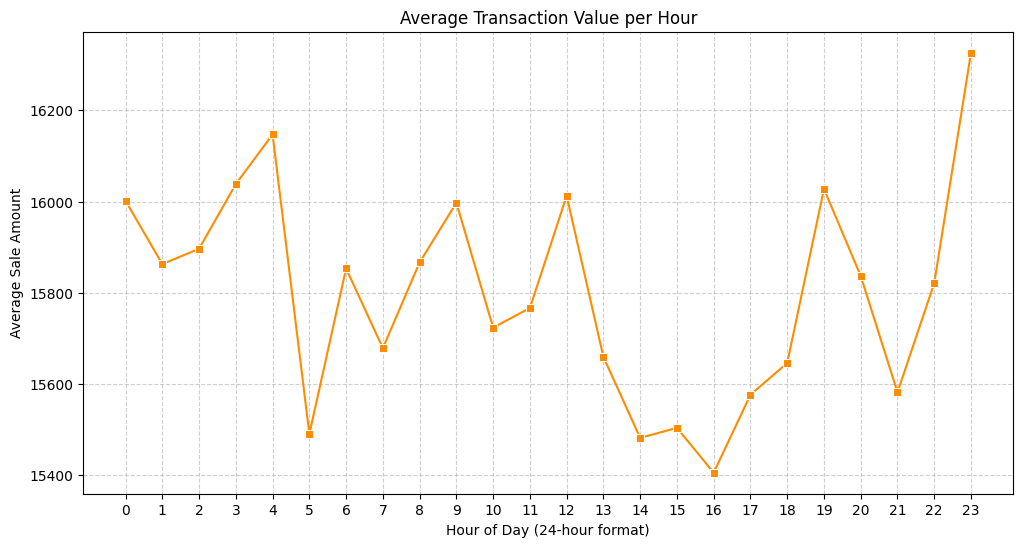

,Hour,Total_Amount
23,23.0,16326.247507
4,4.0,16147.060762
3,3.0,16038.428191
19,19.0,16027.724424
12,12.0,16012.474432


In [282]:
# Calculate average transaction value by hour
avg_val_hour = df.groupby('Hour')['Total_Amount'].mean().reset_index()

# Visualize the results
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_val_hour, x='Hour', y='Total_Amount', marker='s', color='darkorange')
plt.title('Average Transaction Value per Hour')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Average Sale Amount')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Display the top 5 hours with highest average transaction value
display(avg_val_hour.sort_values(by='Total_Amount', ascending=False).head())

### total revenue

In [283]:
round(sum(df["Total_Amount"]))

2253386934

### employees count


In [284]:
df["Role"].value_counts()

,count
Role,
Supervisor,57067
Cashier,51440
Fuel_attendant,34099


### average working hours by role

In [285]:
df.groupby(df['Role'])['Working_Hours'].mean()

,Working_Hours
Role,
Cashier,8.567807
Fuel_attendant,8.997449
Supervisor,8.902834


### average salry of employees


In [286]:
df.groupby(df['Role'])['Salary'].mean()

,Salary
Role,
Cashier,27452.494537
Fuel_attendant,30809.185812
Supervisor,33051.860970


### Rush Hour Analysis
We will analyze transaction counts by hour to identify peak busy times.

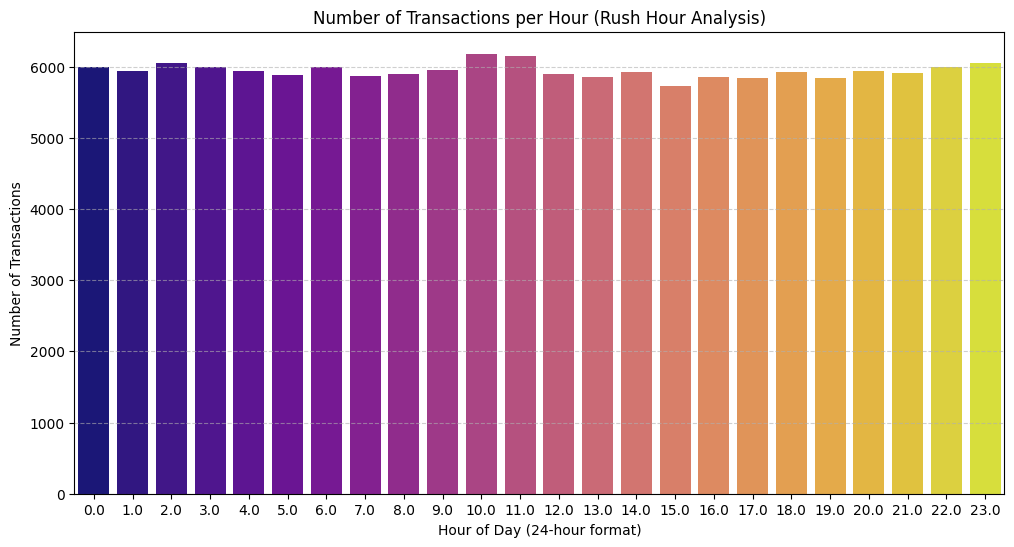

Top 3 busiest hours:


,Hour,Transaction_Count
10,10.0,6181
11,11.0,6154
23,23.0,6054


In [287]:
# Group by hour to find transaction counts
rush_hour_data = df.groupby('Hour').size().reset_index(name='Transaction_Count')

# Visualize transaction frequency by hour
plt.figure(figsize=(12, 6))
sns.barplot(data=rush_hour_data, x='Hour', y='Transaction_Count', palette='plasma', hue='Hour', legend=False)
plt.title('Number of Transactions per Hour (Rush Hour Analysis)')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Identify top 3 rush hours
top_hours = rush_hour_data.sort_values(by='Transaction_Count', ascending=False).head(3)
print('Top 3 busiest hours:')
display(top_hours)

## 7. Executive Summary of Findings

Below is a summary of the key performance indicators and operational insights derived from the dataset:

| Analysis Category | Key Finding | Value / Detail |
| :--- | :--- | :--- |
| **Total Revenue** | Cumulative sales amount | ~2.25 Billion |
| **Top Fuel Type** | Highest revenue generating fuel | Petrol (~1.18B) |
| **Busiest Station** | Counter with most volume | Counter C2 (5.79M Liters) |
| **Peak Hours** | Busiest transaction times | 10:00 AM, 11:00 AM, 11:00 PM |
| **Peak Months** | Highest revenue months | August & October |
| **Staffing Correlation** | Working Hours vs. Total Sales | No correlation (p=0.375) |
| **Workforce** | Largest Employee Group | Supervisors (57,067 records) |
| **Average Salary** | Highest paid role | Supervisor (~33,051) |

### Final Recommendations:
1. **Counter Optimization**: Since Counter C2 is the busiest, consider assigning more experienced staff or additional resources to this station during rush hours.
2. **Inventory Management**: Ensure petrol stocks are prioritized as it accounts for the majority of the revenue.
3. **Staffing Strategy**: Since there is no direct correlation between hours worked and sales volume, focus on training for efficiency rather than simply increasing shift lengths.

# Executive Summary & Operational Insights

## 1. Key Performance Indicators (KPIs)
Based on our analysis of transaction and employee records, here are the primary business metrics:

*   **Total Revenue:** Approximately **2.25 Billion** (Currency Units).
*   **Primary Revenue Driver:** **Petrol** (Generating ~1.18B vs. Diesel's ~1.07B).
*   **Highest Performing Station:** **Counter C2**, processing over **5.79M Liters**.
*   **Peak Operating Months:** **August and October** showed the highest consistent revenue.

## 2. Operational Trends
### Peak Hours (Rush Hour Analysis)
The station experiences three distinct surges in traffic:
1.  **Morning Peak:** 10:00 AM - 11:00 AM (Highest transaction frequency).
2.  **Late Night Surge:** 11:00 PM.

### Transaction Values
*   The average transaction value remains relatively stable throughout the 24-hour cycle, though it peaks slightly during late-night hours (23:00), indicating potentially larger bulk fills during off-peak times.
*   **Weekday vs. Weekend:** There is no significant difference in volume between workdays (~393 transactions/day) and weekends (~388 transactions/day), suggesting a steady customer base.

## 3. Workforce Insights
*   **Staffing Distribution:** The workforce is heavily weighted toward **Supervisors** (57,067 records).
*   **Compensation:** Supervisors are the highest-paid role (Avg: ~33,051), followed by Fuel Attendants and Cashiers.
*   **Sales Performance Correlation:** There is **no statistically significant correlation (p=0.375)** between an employee's working hours and the total sales volume they process. This suggests that simply increasing shift length does not linearly increase sales output.

## 4. Strategic Recommendations

### Resource Allocation
*   **Counter Optimization:** Deploy the most efficient staff or increase the number of active attendants at **Counter C2**, as it consistently handles the highest volume.
*   **Shift Planning:** Align staffing levels with the **10:00 AM - 11:00 AM** and **11:00 PM** rush hours to reduce wait times and prevent congestion.

### Inventory & Marketing
*   **Fuel Stocking:** Prioritize Petrol inventory management, as it is the station's primary revenue source.
*   **Off-Peak Incentives:** Since there is a drop-off in transaction frequency in the early morning (5:00 AM - 7:00 AM), consider loyalty rewards or promotions during these hours to balance the load.

### Employee Management
*   **Efficiency Training:** Since sales are not correlated with hours worked, focus on **transaction speed training** rather than overtime. Productivity is likely driven by station location and time-of-day rather than shift duration.

In [288]:
df.head()

,Invoice_ID,DateTime,EmpID,Counter_Station,Fuel_Type,Liters_Sold,Price_Per_Liter,Total_Amount,Payment_Method,Employee_Name,...,Gender,Role,Working_Hours,Joining_Date,Salary,Phone_Number,Month,Hour,Day_Name,Is_Weekend
0,INV20240902-0001,2024-09-02 13:31:00,EMP023,C4,Petrol,75.03,100.79,7562.27,Cash,Priya sharma,...,FEMALE,Supervisor,10,2019-01-25,24583.0,9113220074,Sep,13.0,Monday,False
1,INV20241215-0002,2024-12-15 21:08:00,EMP009,C2,Petrol,143.51,101.81,14610.75,Cash,Neha nair,...,Female,Fuel_attendant,6,2020-06-01,22454.0,934245850,Dec,21.0,Sunday,True
2,INV20240728-0003,2024-07-28 01:37:00,EMP005,C1,Petrol,194.60,107.25,20870.85,Card,Deepak verma,...,male,Supervisor,6,2019-12-14,12491.0,972021653,Jul,1.0,Sunday,True
3,inv20240626-0004,2024-06-26 13:16:00,EMP007,C2,Petrol,88.80,107.58,9553.10,Upi,Vivek menon,...,male,Fuel_attendant,10,2020-11-15,80000.0,9129876770,Jun,13.0,Wednesday,False
4,INV20241006-0005,2024-06-10 14:17:00,EMP001,C1,Petrol,34.54,95.68,3304.79,Card,Ramesh kumar,...,FEMALE,Supervisor,10,2019-05-20,80000.0,9945175914,Jun,14.0,Monday,False
